In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join('..')))

In [2]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import optuna
from src.preprocessing import process_dataframe
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader
from src._lstm import CNNLSTMRegressor, train_lstm_recursive_val, predict
from src.visualization import plot_forecast
from sklearn.metrics import root_mean_squared_error

C:\Users\Ivan\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df_train_full = pd.read_csv('../data/processed/train_raw, ZK 68, (48-1, 48-air), 27.11.20-31.12.24.csv', parse_dates=['Дата'])
df_train_full.index = df_train_full['Дата']

df_test = pd.read_csv('../data/processed/test_raw, ZK 68, (48-1, 48-air), 01.01.25-15.12.25.csv', parse_dates=['Дата'])
df_test.index = df_test['Дата']

df_train = df_train_full[:'2023-12-31'].copy()
df_val = df_train_full['2024-01-01':].copy()

In [4]:
df_train_full = process_dataframe(df_train_full)
df_train = process_dataframe(df_train)
df_val = process_dataframe(df_val)
df_test = process_dataframe(df_test)

In [5]:
target_cols = ['48-1 (0)','48-1 (0,5)', '48-1 (1)', '48-1 (1,5)','48-1 (2)', '48-1 (2,5)', '48-1 (3)', 
               '48-1 (3,5)', '48-1 (4)', '48-1 (4,5)', '48-1 (5)', '48-1 (6)', '48-1 (7)', '48-1 (8)', 
               '48-1 (9)', '48-1 (10)']
features_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 
                 'day_of_year_cos', 'days_from_start', 'is_anomaly']
lags_length = 14

df_train_full = df_train_full[features_cols + target_cols]
df_train = df_train[features_cols + target_cols]
df_val = df_val[features_cols + target_cols]
df_test = df_test[features_cols + target_cols]

In [6]:
feature_scaler = StandardScaler()
target_scaler = StandardScaler()

train_features_scaled = feature_scaler.fit_transform(df_train[features_cols])
train_target_scaled = target_scaler.fit_transform(df_train[target_cols])

train_scaled = np.hstack((train_features_scaled, train_target_scaled))

val_start = df_train[-lags_length:]
df_full_val = pd.concat([val_start, df_val])

val_features_scaled = feature_scaler.transform(df_full_val[features_cols])
val_target_scaled = target_scaler.transform(df_full_val[target_cols])

val_scaled = np.hstack((val_features_scaled, val_target_scaled))

target_col_index = train_scaled.shape[1] - 1

In [7]:
full_feature_scaler = StandardScaler()
full_target_scaler = StandardScaler()

full_train_features_scaled = full_feature_scaler.fit_transform(df_train_full[features_cols])
full_train_target_scaled = full_target_scaler.fit_transform(df_train_full[target_cols])

full_train_scaled = np.hstack((full_train_features_scaled, full_train_target_scaled))

In [8]:
def create_sequences(data, target_start_index, lags_length):
    X, y = [], []
    for i in range(len(data) - lags_length):
        X.append(data[i : i + lags_length])
        y.append(data[i + lags_length, target_start_index:])
    return torch.tensor(np.array(X), dtype=torch.float32), torch.tensor(np.array(y), dtype=torch.float32)

target_start_index = len(features_cols)

X_train, y_train = create_sequences(train_scaled, target_start_index, lags_length)
X_val, y_val = create_sequences(val_scaled, target_start_index, lags_length)
X_full_train, y_full_train = create_sequences(full_train_scaled, target_start_index, lags_length)

In [9]:
batch_size = 32
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [10]:
criterion = nn.MSELoss()

num_features = len(features_cols)
num_depths = len(target_cols)

def objective(trial):
    kernel_depth = trial.suggest_int('kernel_depth', 1, 5, step=2)
    kernel_time = trial.suggest_int('kernel_time', 1, 5, step=2)
    out_channels = trial.suggest_int('out_channels', 16, 64, step=16)
    lstm_hidden_size = trial.suggest_int('lstm_hidden_size', 16, 112, step=16)
    lstm_num_layers = trial.suggest_int('lstm_num_layers', 1, 3)
    lr = trial.suggest_float('lr', 1e-5, 1e-2, log=True)

    model_trial = CNNLSTMRegressor(
        num_features=num_features,
        num_depths=num_depths,
        kernel_depth=kernel_depth,
        kernel_time=kernel_time,
        out_channels=out_channels,
        lstm_hidden_size=lstm_hidden_size,
        lstm_num_layers=lstm_num_layers,
    ).to(device)
    optimizer_trial = torch.optim.Adam(model_trial.parameters(), lr=lr)

    model_trial, val_hist = train_lstm_recursive_val(
        model=model_trial,
        criterion=criterion,
        optimizer=optimizer_trial,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        epochs=50,
        max_epochs_no_improvement=10,
        verbose=False
    )
    
    trial.set_user_attr('total_epochs', len(val_hist) - 1)

    best_val_rmse = min(val_hist)
    return best_val_rmse

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)

print("Лучшие параметры: ", study.best_params)
print("Количество эпох в лучшем запуске: ", study.best_trial.user_attrs['total_epochs'])

[I 2026-05-28 18:08:01,612] A new study created in memory with name: no-name-9b014273-046e-46e7-903c-ce3a1d726180
[I 2026-05-28 18:08:28,978] Trial 0 finished with value: 0.37677067518234253 and parameters: {'kernel_depth': 5, 'kernel_time': 5, 'out_channels': 32, 'lstm_hidden_size': 112, 'lstm_num_layers': 3, 'lr': 0.002346486165226364}. Best is trial 0 with value: 0.37677067518234253.


Early stopping on 32 epoch


[I 2026-05-28 18:08:50,083] Trial 1 finished with value: 0.1860228180885315 and parameters: {'kernel_depth': 3, 'kernel_time': 1, 'out_channels': 32, 'lstm_hidden_size': 96, 'lstm_num_layers': 3, 'lr': 0.0003334552565573393}. Best is trial 1 with value: 0.1860228180885315.


Early stopping on 28 epoch


[I 2026-05-28 18:09:04,773] Trial 2 finished with value: 0.3152744770050049 and parameters: {'kernel_depth': 5, 'kernel_time': 1, 'out_channels': 32, 'lstm_hidden_size': 80, 'lstm_num_layers': 1, 'lr': 2.3708617034244538e-05}. Best is trial 1 with value: 0.1860228180885315.


...

Early stopping on 41 epoch


[I 2026-05-28 18:10:54,595] Trial 8 finished with value: 0.24511387944221497 and parameters: {'kernel_depth': 3, 'kernel_time': 5, 'out_channels': 16, 'lstm_hidden_size': 48, 'lstm_num_layers': 3, 'lr': 0.001000568800378795}. Best is trial 1 with value: 0.1860228180885315.


Early stopping on 33 epoch


[I 2026-05-28 18:11:05,712] Trial 9 finished with value: 0.9103114604949951 and parameters: {'kernel_depth': 3, 'kernel_time': 5, 'out_channels': 48, 'lstm_hidden_size': 48, 'lstm_num_layers': 1, 'lr': 2.552630994371013e-05}. Best is trial 1 with value: 0.1860228180885315.


Early stopping on 29 epoch
Лучшие параметры:  {'kernel_depth': 3, 'kernel_time': 1, 'out_channels': 32, 'lstm_hidden_size': 96, 'lstm_num_layers': 3, 'lr': 0.0003334552565573393}
Количество эпох в лучшем запуске:  28


In [11]:
model = CNNLSTMRegressor(
    num_features=num_features,
    num_depths=num_depths,
    kernel_depth=study.best_params['kernel_depth'],
    kernel_time=study.best_params['kernel_time'],
    out_channels=study.best_params['out_channels'],
    lstm_hidden_size=study.best_params['lstm_hidden_size'],
    lstm_num_layers=study.best_params['lstm_num_layers'],
).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=study.best_params['lr'])

model, _ = train_lstm_recursive_val(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    train_loader=train_loader,
    device=device,
    epochs=study.best_trial.user_attrs['total_epochs'],
    max_epochs_no_improvement=10,
    verbose=True
)

Epoch 1/28, Train Loss: 0.9255
Epoch 2/28, Train Loss: 0.4670
Epoch 3/28, Train Loss: 0.2081
Epoch 4/28, Train Loss: 0.2356
Epoch 5/28, Train Loss: 0.1292
Epoch 6/28, Train Loss: 0.1038
Epoch 7/28, Train Loss: 0.0737
Epoch 8/28, Train Loss: 0.0791
Epoch 9/28, Train Loss: 0.0705
Epoch 10/28, Train Loss: 0.0842
Epoch 11/28, Train Loss: 0.0468
Epoch 12/28, Train Loss: 0.0344
Epoch 13/28, Train Loss: 0.0257
Epoch 14/28, Train Loss: 0.0277
Epoch 15/28, Train Loss: 0.0392
Epoch 16/28, Train Loss: 0.0417
Epoch 17/28, Train Loss: 0.0349
Epoch 18/28, Train Loss: 0.0823
Epoch 19/28, Train Loss: 0.0489
Epoch 20/28, Train Loss: 0.0253
Epoch 21/28, Train Loss: 0.0248
Epoch 22/28, Train Loss: 0.0216
Epoch 23/28, Train Loss: 0.0214
Epoch 24/28, Train Loss: 0.0198
Epoch 25/28, Train Loss: 0.0155
Epoch 26/28, Train Loss: 0.0201
Epoch 27/28, Train Loss: 0.0167
Epoch 28/28, Train Loss: 0.0173


In [13]:
model_path = "models/lstm_v2.pth"
weights_path = "models/lstm_v2_weights.pth"

In [14]:
torch.save(model, model_path)
torch.save(model.state_dict(), weights_path)

In [15]:
model = torch.load(model_path, weights_only=False)

Test RMSE: 1.7513
RMSE for 48-1 (0): 5.2241


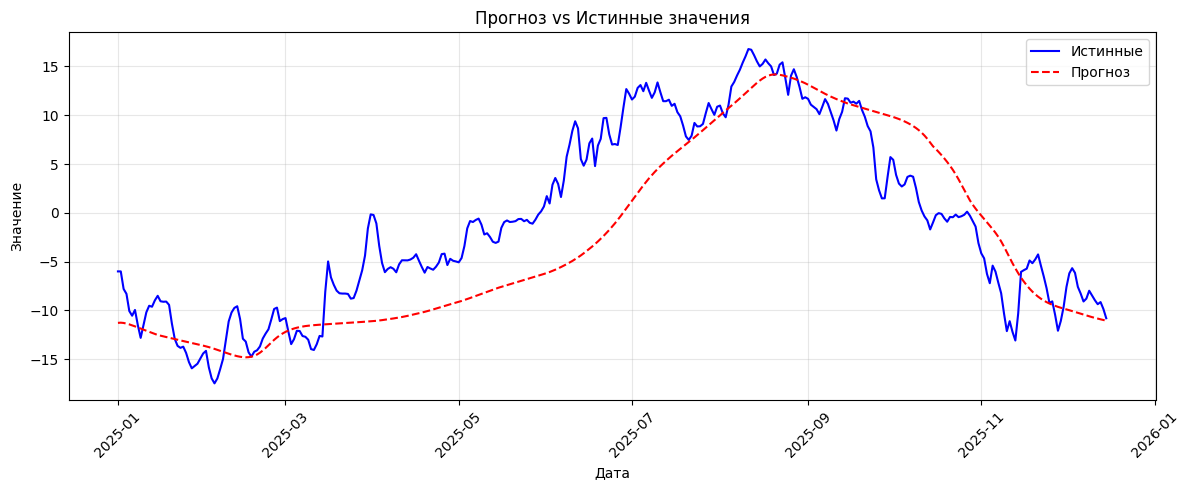

RMSE for 48-1 (0,5): 3.7144


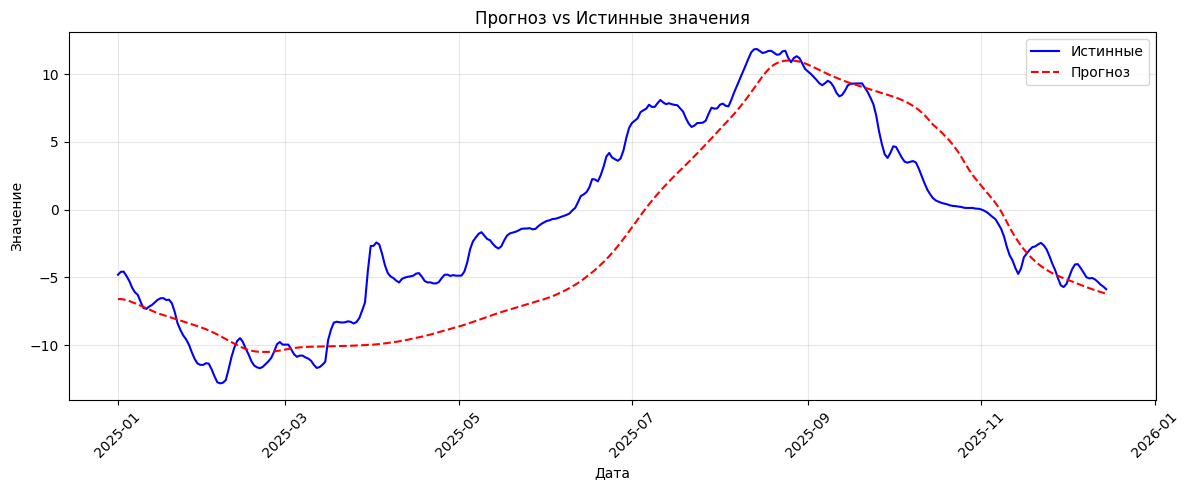

RMSE for 48-1 (1): 2.7481


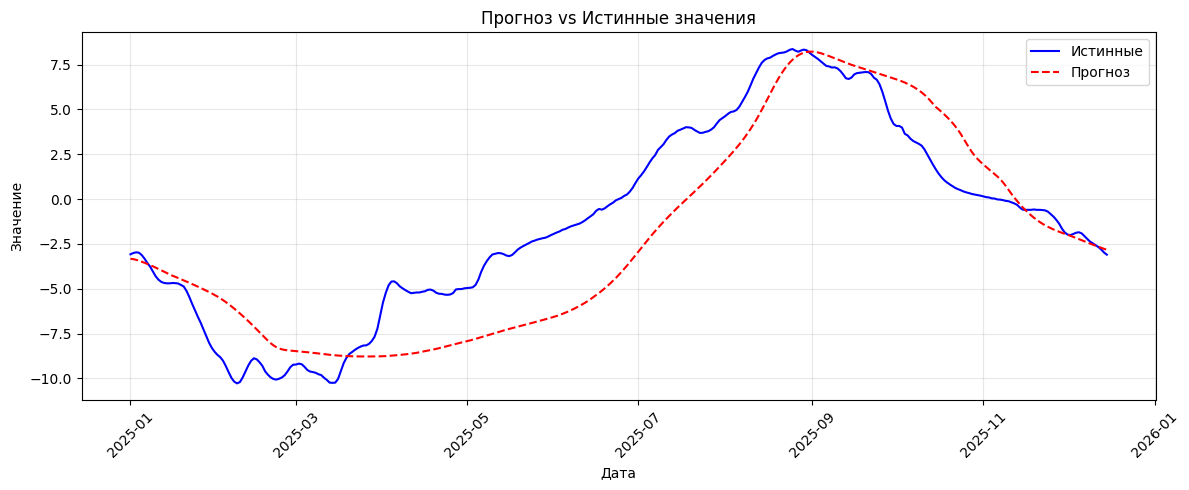

RMSE for 48-1 (1,5): 2.3428


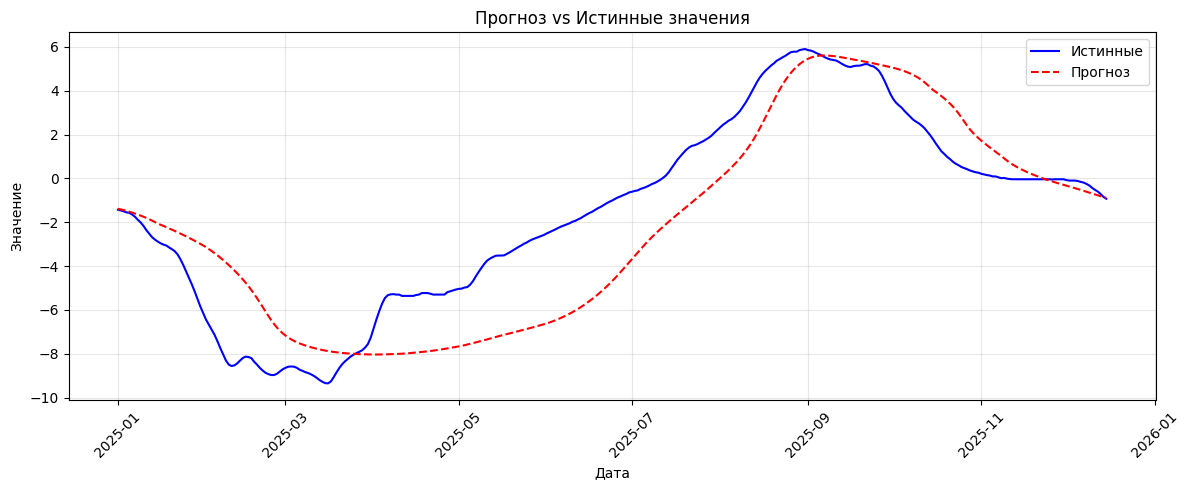

RMSE for 48-1 (2): 2.0359


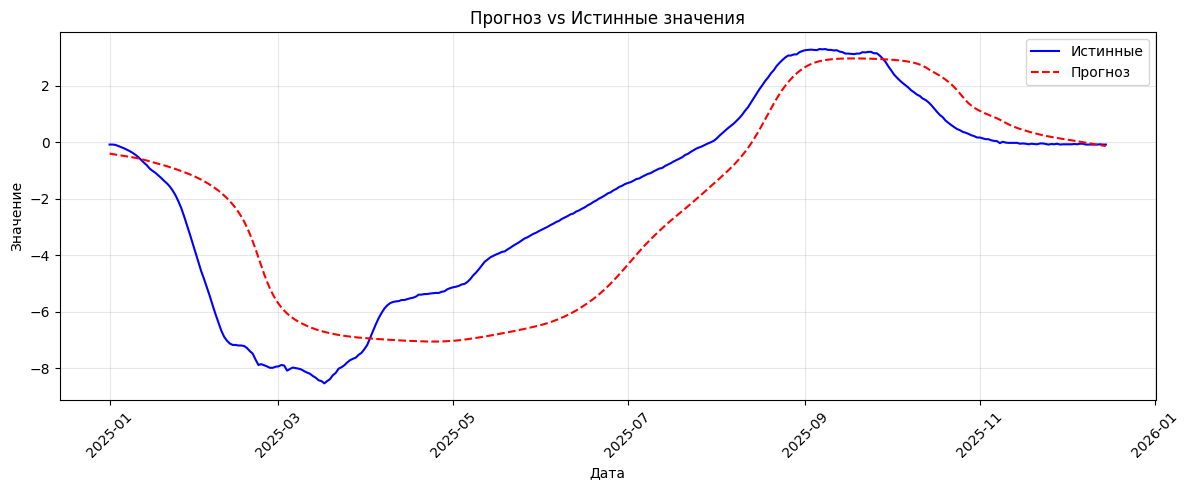

RMSE for 48-1 (2,5): 1.8052


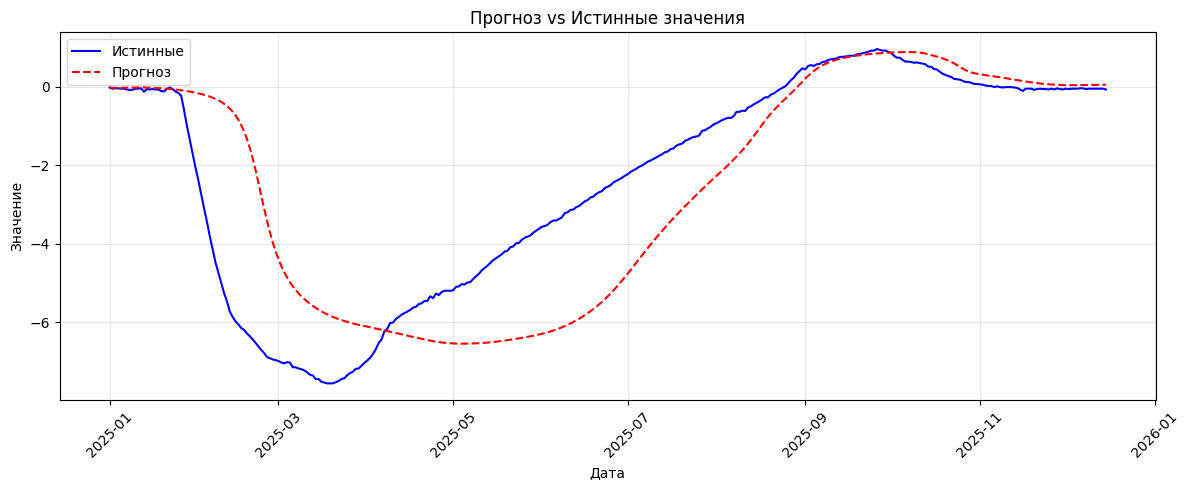

RMSE for 48-1 (3): 1.5906


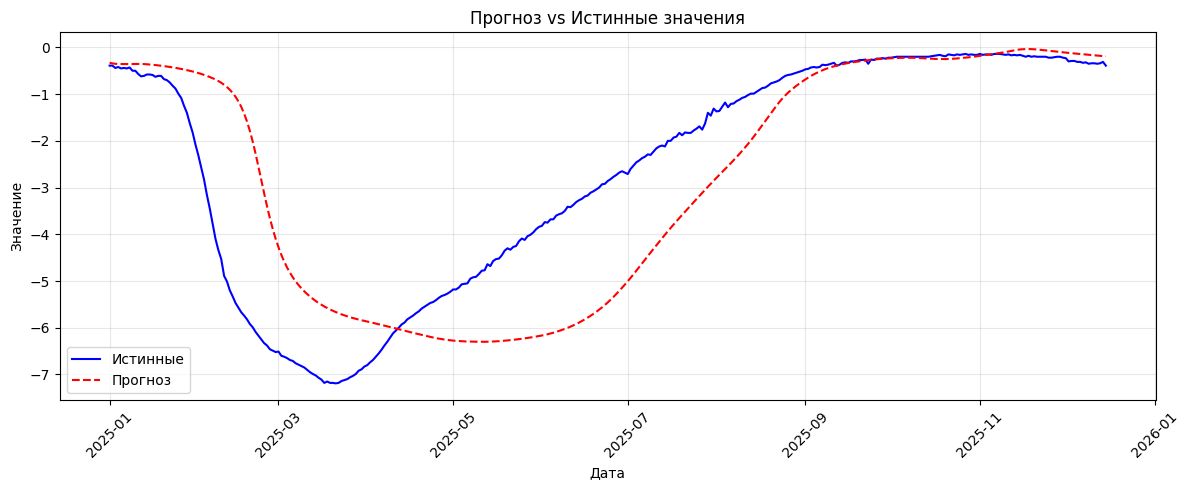

RMSE for 48-1 (3,5): 1.4054


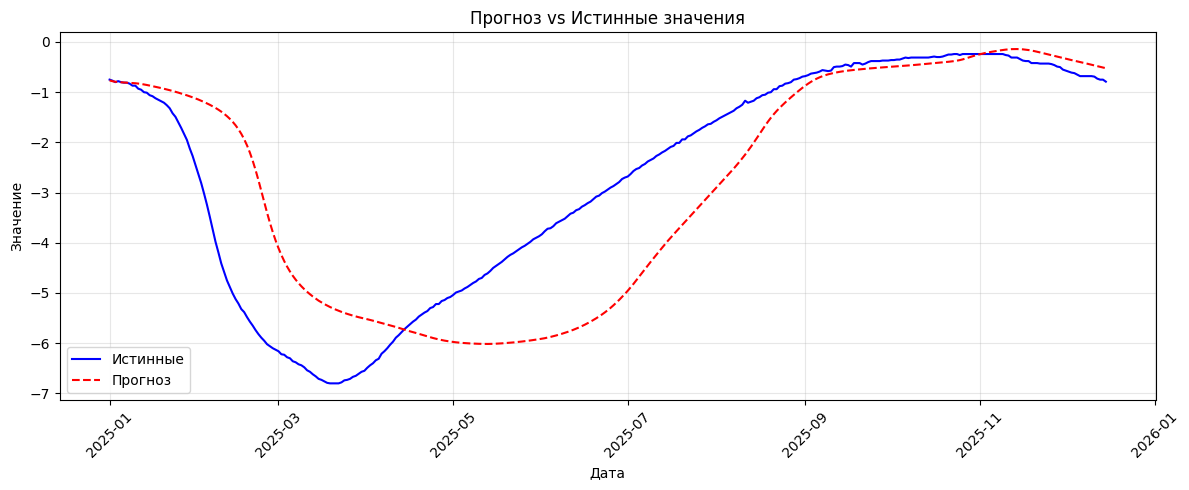

RMSE for 48-1 (4): 1.2141


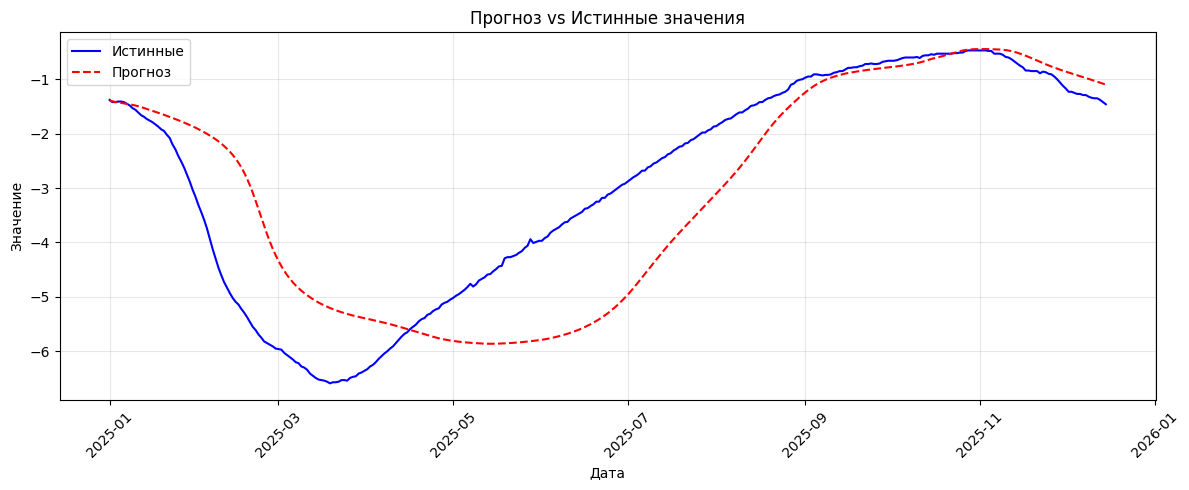

RMSE for 48-1 (4,5): 1.1532


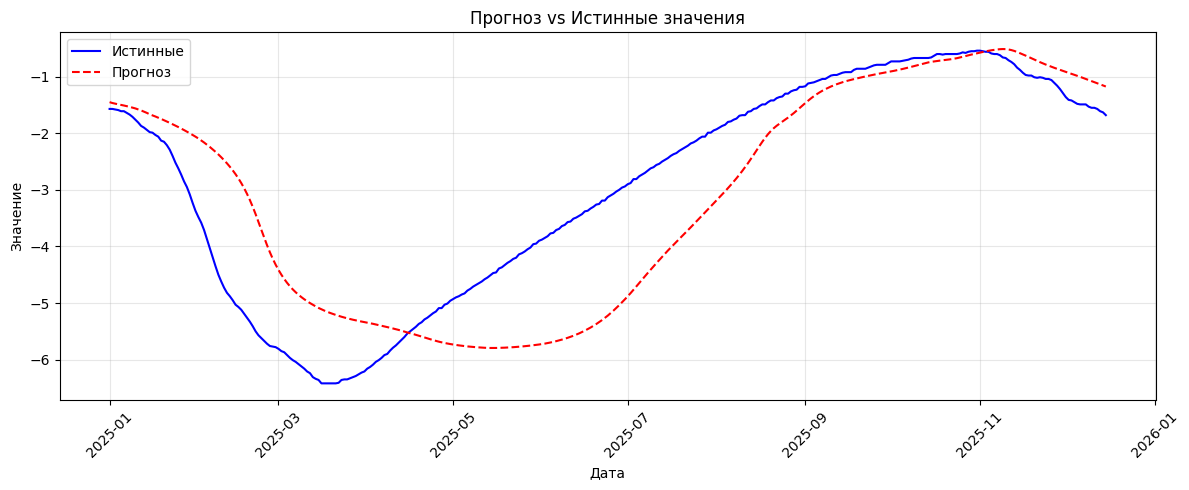

RMSE for 48-1 (5): 1.0688


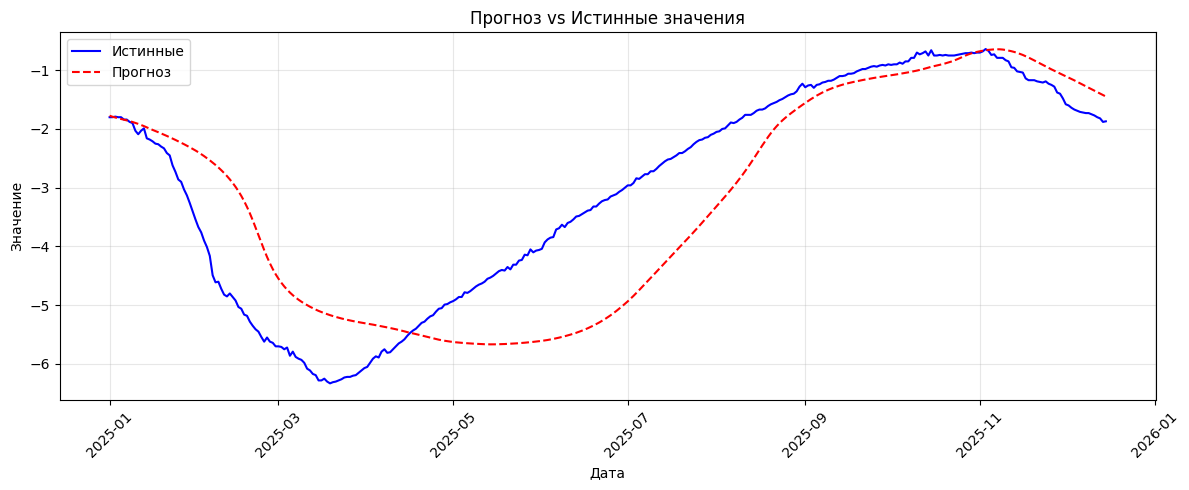

RMSE for 48-1 (6): 0.9819


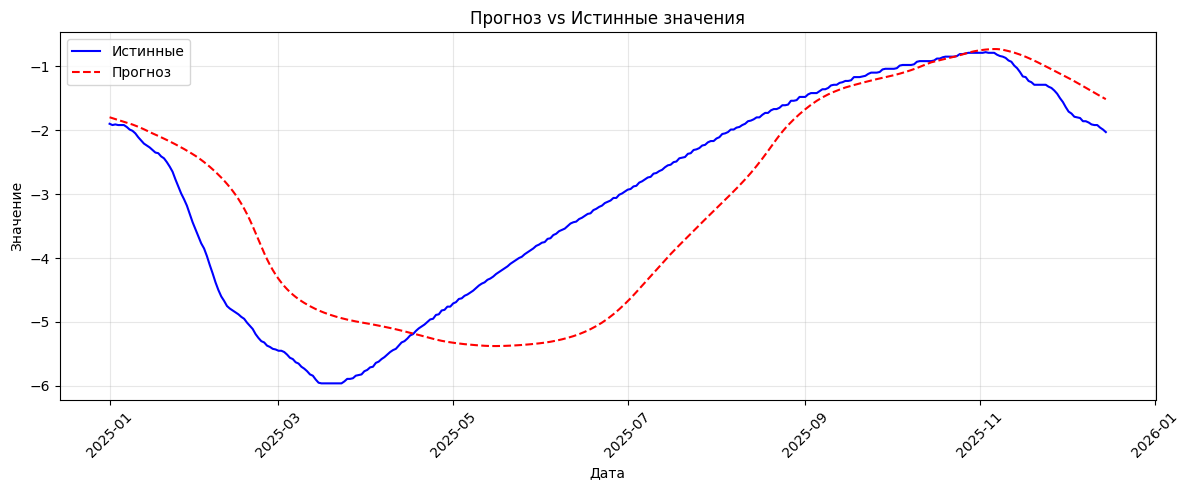

RMSE for 48-1 (7): 0.8813


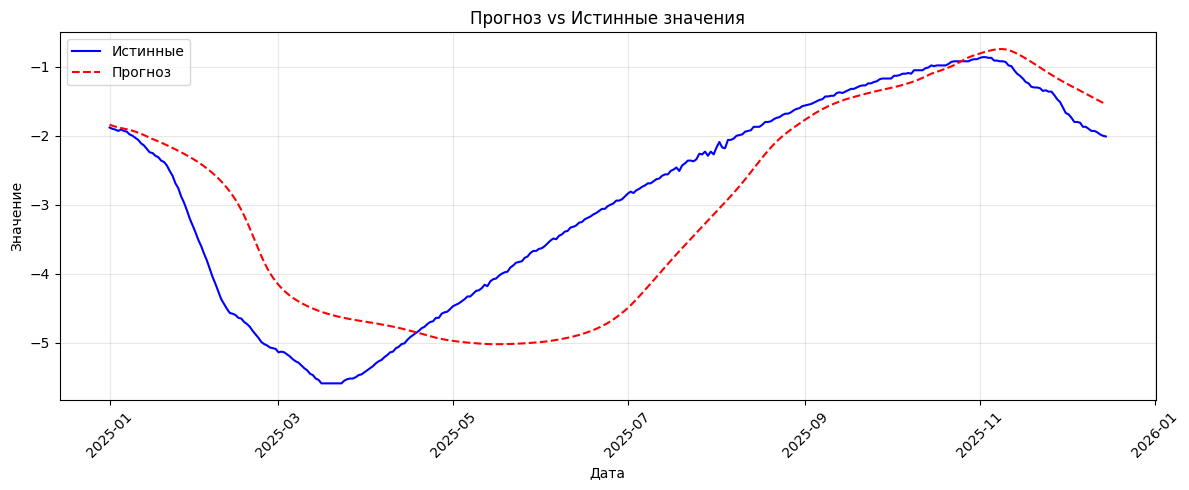

RMSE for 48-1 (8): 0.7710


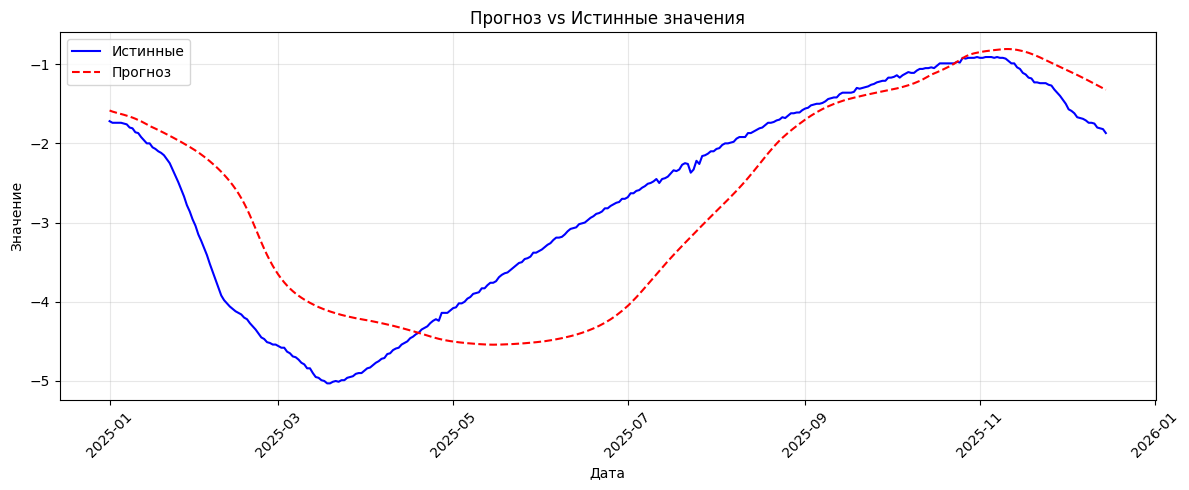

RMSE for 48-1 (9): 0.6089


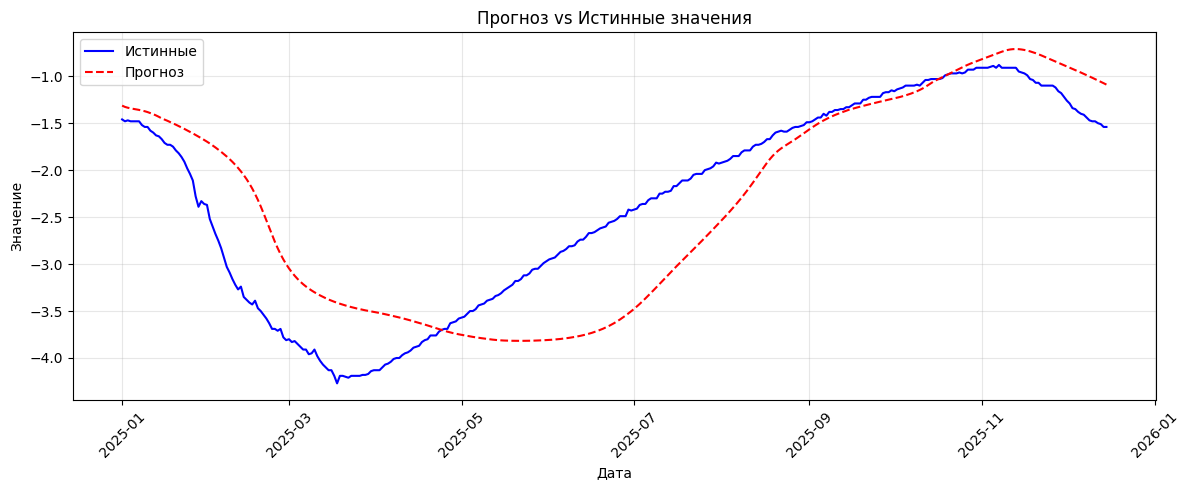

RMSE for 48-1 (10): 0.4759


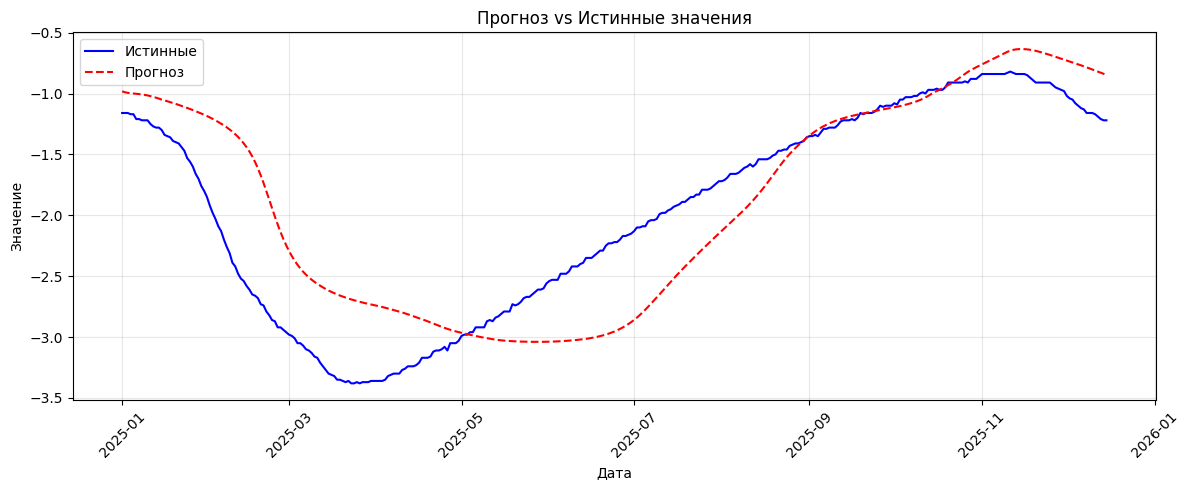

In [16]:
test_start = df_train_full[-lags_length:]

start_features_scaled = feature_scaler.transform(test_start[features_cols])
start_target_scaled = target_scaler.transform(test_start[target_cols])

current_lags = np.hstack((start_features_scaled, start_target_scaled))

future_features_scaled = feature_scaler.transform(df_test[features_cols])

start_lags_tensor = torch.tensor(current_lags, dtype=torch.float32)
future_features_tensor = torch.tensor(future_features_scaled, dtype=torch.float32)

y_pred_scaled = predict(model, start_lags_tensor, future_features_tensor, device=device)

y_pred = target_scaler.inverse_transform(y_pred_scaled)
y_true = df_test[target_cols].values

rmse = root_mean_squared_error(y_true, y_pred)
print(f"Test RMSE: {rmse:.4f}")

rmse_per_depth = root_mean_squared_error(y_true, y_pred, multioutput='raw_values')
for i, col in enumerate(target_cols):
    rmse = rmse_per_depth[i]
    print(f'RMSE for {col}: {rmse:.4f}')
    
    s_true = pd.Series(y_true[:, i], index=df_test.index)
    s_pred = pd.Series(y_pred[:, i], index=df_test.index)
    
    plot_forecast(pd.DataFrame(s_true), pd.DataFrame(s_pred))